In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/ipums_acs/usa_00001.csv")
new_df = df[df["YEAR"]>= 2014]
new_df.head()


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEFIP,STRATA,GQ,PERNUM,PERWT,BPL,BPLD,CITIZEN,EDUC,EDUCD,OCC,INCTOT
50520719,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,1,52.0,1,100,0.0,6.0,63.0,7210.0,45000.0
50520720,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,2,35.0,1,100,0.0,0.0,2.0,0.0,0.0
50520721,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,3,198.0,1,100,0.0,0.0,2.0,6200.0,0.0
50520722,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,4,101.0,1,100,0.0,2.0,26.0,0.0,0.0
50520723,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,5,95.0,1,100,0.0,2.0,26.0,0.0,9999999.0


In [10]:
#Filter out the post-2024 data and make chunks
input_raw = "../data/raw/ipums_acs/usa_00001.csv"
output_2014 = "../data/raw/ipums_acs/usa_2014_plus.csv"
first_chunk = True
for chunk in pd.read_csv(input_raw, chunksize=100000):
    filtered = chunk[chunk["YEAR"]>= 2014]

    if first_chunk:
            filtered.to_csv(output_2014, mode='w', index=False, header=True)
            first_chunk = False
    else:
        filtered.to_csv(output_2014, mode='a', index=False, header=False)
parqueth = "../data/raw/ipums_acs/usa_2014_plus.parquet"
par_output_2014 = pd.read_csv(output_2014)
par_output_2014.to_parquet(parqueth, engine='pyarrow', index=False)
print("Done")


Done


In [11]:
parquet_path = "../data/raw/ipums_acs/usa_2014_plus.parquet"
df = pd.read_parquet(parqueth, columns = ['YEAR', 'STATEFIP', 'BPL', 'CITIZEN',
      'EDUC', 'OCC', 'INCTOT', 'PERWT'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35175962 entries, 0 to 35175961
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   YEAR      int64  
 1   STATEFIP  int64  
 2   BPL       int64  
 3   CITIZEN   int64  
 4   EDUC      int64  
 5   OCC       int64  
 6   INCTOT    int64  
 7   PERWT     float64
dtypes: float64(1), int64(7)
memory usage: 2.1 GB


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35175962 entries, 0 to 35175961
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   YEAR      int64  
 1   STATEFIP  int64  
 2   BPL       int64  
 3   CITIZEN   int64  
 4   EDUC      int64  
 5   OCC       int64  
 6   INCTOT    int64  
 7   PERWT     float64
dtypes: float64(1), int64(7)
memory usage: 2.1 GB


In [13]:
# 1. Handle missing codes
missing_codes = {
    'INCTOT': 9999999, 
    'OCC': 0, 
    'EDUC': 0, 
    'CITIZEN': 0
}
# Replace missing codes with NaN to avoid statistical skew
for col, code in missing_codes.items():
    df[col] = df[col].replace(code, np.nan)
    
# Drop rows where critical variables (Education or Occupation) are NaN
df_clean = df.dropna(subset=['EDUC', 'OCC']).copy()
print(f"Data shape after cleaning: {df_clean.shape}")

Data shape after cleaning: (20606293, 8)


In [14]:
df_clean['highly_educated'] = df_clean['EDUC'] >= 10
df_clean['low_skill_job'] = df_clean['OCC'] >= 3600

df_clean['is_brain_waste'] = df_clean['highly_educated'] & df_clean['low_skill_job']

print("Total Highly Educated in sample:", df_clean['highly_educated'].sum())
print("Total Brain Waste Cases in sample:", df_clean['is_brain_waste'].sum())

Total Highly Educated in sample: 7339648
Total Brain Waste Cases in sample: 1975044


In [15]:
df_clean['is_imigrant'] = df_clean['BPL'] >= 100

educated_only = df_clean[df_clean['highly_educated'] == True].copy()

agg_df = educated_only.groupby(['YEAR', 'STATEFIP','is_imigrant']).apply(
    lambda x: pd.Series({
        'total_educated_pop': x['PERWT'].sum(),
        'brain_waste_pop': (x['is_brain_waste']* x['PERWT']).sum()
    }), include_groups=False
).reset_index()

# Calculate the actual percentage of brain waste
agg_df['brain_waste_pct'] = (agg_df['brain_waste_pop'] / agg_df['total_educated_pop']) * 100
print(agg_df.head(10))

   YEAR  STATEFIP  is_imigrant  total_educated_pop  brain_waste_pop  \
0  2014         1        False            619622.0         196873.0   
1  2014         1         True             41711.0          14445.0   
2  2014         2        False            114147.0          34176.0   
3  2014         2         True             16653.0           5927.0   
4  2014         4        False            859902.0         270683.0   
5  2014         4         True            148765.0          44554.0   
6  2014         5        False            345633.0         102466.0   
7  2014         5         True             26664.0           8352.0   
8  2014         6        False           4927188.0        1389668.0   
9  2014         6         True           2205661.0         668932.0   

   brain_waste_pct  
0        31.773081  
1        34.631152  
2        29.940340  
3        35.591185  
4        31.478355  
5        29.949249  
6        29.645896  
7        31.323132  
8        28.204079  
9       

In [16]:
# IPUMS FIPS to US State Mapping
fips_to_state = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
    8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia',
    12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois',
    18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
    23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
    27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
    35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota',
    39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island',
    45: 'South Carolina', 46: 'South Dakota', 47: 'Tennessee', 48: 'Texas',
    49: 'Utah', 50: 'Vermont', 51: 'Virginia', 53: 'Washington', 54: 'West Virginia',
    55: 'Wisconsin', 56: 'Wyoming'
}

# Create a new column with the human-readable state name
agg_df['US_State'] = agg_df['STATEFIP'].map(fips_to_state)

# 🔴 UPDATE: Added 'YEAR' to the column reordering
agg_df = agg_df[['YEAR', 'STATEFIP', 'US_State', 'is_imigrant', 'total_educated_pop', 'brain_waste_pop', 'brain_waste_pct']]

print(agg_df.head())


   YEAR  STATEFIP US_State  is_imigrant  total_educated_pop  brain_waste_pop  \
0  2014         1  Alabama        False            619622.0         196873.0   
1  2014         1  Alabama         True             41711.0          14445.0   
2  2014         2   Alaska        False            114147.0          34176.0   
3  2014         2   Alaska         True             16653.0           5927.0   
4  2014         4  Arizona        False            859902.0         270683.0   

   brain_waste_pct  
0        31.773081  
1        34.631152  
2        29.940340  
3        35.591185  
4        31.478355  


In [17]:
import os

# 1. Create a "processed" folder if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# 2. Save your aggregated calculations as both JSON and CSV
agg_df.to_json('../data/processed/brain_waste_by_region.json', orient='records')
agg_df.to_csv('../data/processed/brain_waste_by_region.csv', index=False)

print("✅ Data successfully saved! You no longer need to run the raw IPUMS data cells.")


✅ Data successfully saved! You no longer need to run the raw IPUMS data cells.


In [18]:
# 1. Map BPL codes to World Regions & Top Origins
def map_bpl_to_region(bpl):
    if bpl < 100:
        return "Native-born (USA)"
    elif bpl == 200:
        return "Mexico"
    elif bpl == 530:
        return "India"
    elif 500 <= bpl <= 510:
        return "China/East Asia"
    elif bpl == 515:
        return "Philippines"
    elif 500 <= bpl < 600:
        return "Other Asia"
    elif 400 <= bpl < 500:
        return "Europe"
    elif 200 <= bpl < 400:
        return "Central/South America & Caribbean"
    elif 600 <= bpl < 700:
        return "Africa"
    else:
        return "Other Immigrants"

# Apply the mapping to our educated subset
educated_only['Origin_Region'] = educated_only['BPL'].apply(map_bpl_to_region)

# 2. Run the Aggregation including the new Origin_Region
agg_region_df = educated_only.groupby(['STATEFIP', 'Origin_Region']).apply(
    lambda x: pd.Series({
        'total_educated_pop': x['PERWT'].sum(),
        'brain_waste_pop': (x['is_brain_waste'] * x['PERWT']).sum()
    }), include_groups=False
).reset_index()

# 3. Calculate percentages
agg_region_df['brain_waste_pct'] = (agg_region_df['brain_waste_pop'] / agg_region_df['total_educated_pop']) * 100

# 4. Map the US_State names (using the dictionary from earlier)
agg_region_df['US_State'] = agg_region_df['STATEFIP'].map(fips_to_state)

# Sort to see the largest populations first
print(agg_region_df.sort_values(by='total_educated_pop', ascending=False).head(15))


     STATEFIP      Origin_Region  total_educated_pop  brain_waste_pop  \
41          6  Native-born (USA)          62090803.0       16486199.0   
392        48  Native-born (USA)          45606410.0       12255378.0   
293        36  Native-born (USA)          39012657.0       10511402.0   
86         12  Native-born (USA)          31033893.0        9503731.0   
347        42  Native-born (USA)          25999889.0        7087664.0   
122        17  Native-born (USA)          25677946.0        7232232.0   
320        39  Native-born (USA)          21403134.0        5813787.0   
302        37  Native-born (USA)          20161100.0        5818582.0   
95         13  Native-born (USA)          18989576.0        5487306.0   
419        51  Native-born (USA)          18779705.0        4700666.0   
275        34  Native-born (USA)          18394449.0        5036953.0   
194        25  Native-born (USA)          17875028.0        4534534.0   
203        26  Native-born (USA)          17672098.

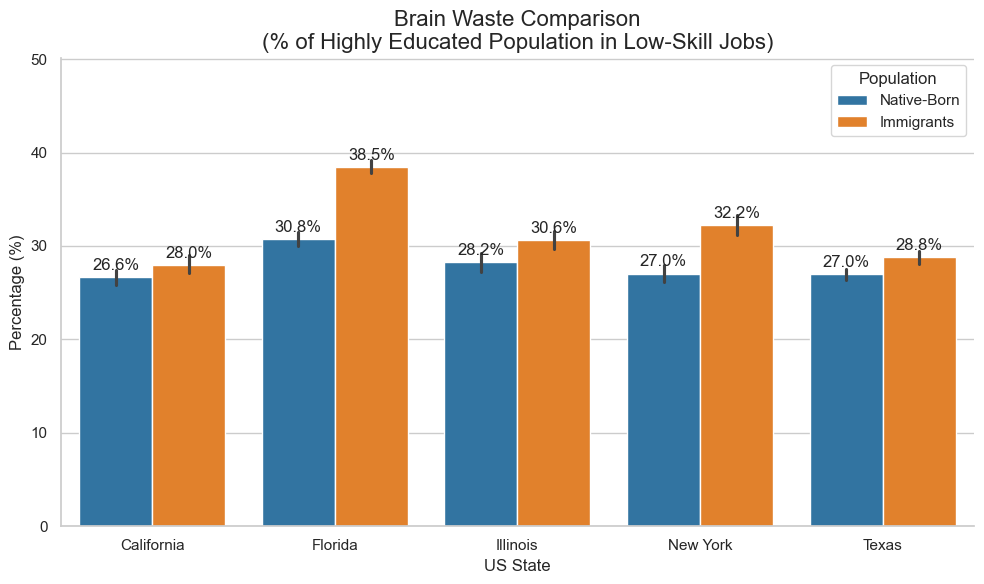

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Load the pre-calculated, lightweight dataset instantly
agg_df = pd.read_json('../data/processed/brain_waste_by_region.json')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16})

top_states = [6, 48, 36, 12, 17]
state_names = {6: 'California', 48: 'Texas', 36: 'New York', 12: 'Florida', 17: 'Illinois'}

plot_df = agg_df[agg_df['STATEFIP'].isin(top_states)].copy()
plot_df['State Name'] = plot_df['STATEFIP'].map(state_names)
plot_df['Population'] = plot_df['is_imigrant'].map({True: 'Immigrants', False: 'Native-Born'})

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_df, 
    x='State Name', 
    y='brain_waste_pct', 
    hue='Population',
    palette=['#1f77b4', '#ff7f0e'] # Blue and Orange
)
plt.title('Brain Waste Comparison\n(% of Highly Educated Population in Low-Skill Jobs)')
plt.ylabel('Percentage (%)')
plt.xlabel('US State')
# Add percentage labels on top of the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
# Expand Y-axis slightly so labels fit
plt.ylim(0, plot_df['brain_waste_pct'].max() + 10)
sns.despine()
plt.tight_layout()
plt.show()

In [20]:
# Load the CSV, stripping the spaces after commas
founders_df = pd.read_csv('../data/raw/founders/eu_tech_founders_stats.csv', skipinitialspace=True)

# Strip whitespace from column NAMES AND all string cell values
# (The CSV has trailing spaces in every cell, not just headers)
founders_df.columns = founders_df.columns.str.strip()
founders_df = founders_df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Filter out the "percent_increase" row so we are only comparing standard percentages (0-100)
percent_df = founders_df[founders_df['unit'] == 'percent'].copy()
print(f'Rows after filter: {len(percent_df)}')  # Should print 6

# Create a readable label combining the region and metric
percent_df['metric_clean'] = percent_df['metric'].str.replace('_', ' ').str.title()
percent_df['label'] = percent_df['country_or_region'] + " - " + percent_df['metric_clean']

# Sort for a clean horizontal cascade
percent_df = percent_df.sort_values(by='value', ascending=True)


Rows after filter: 7


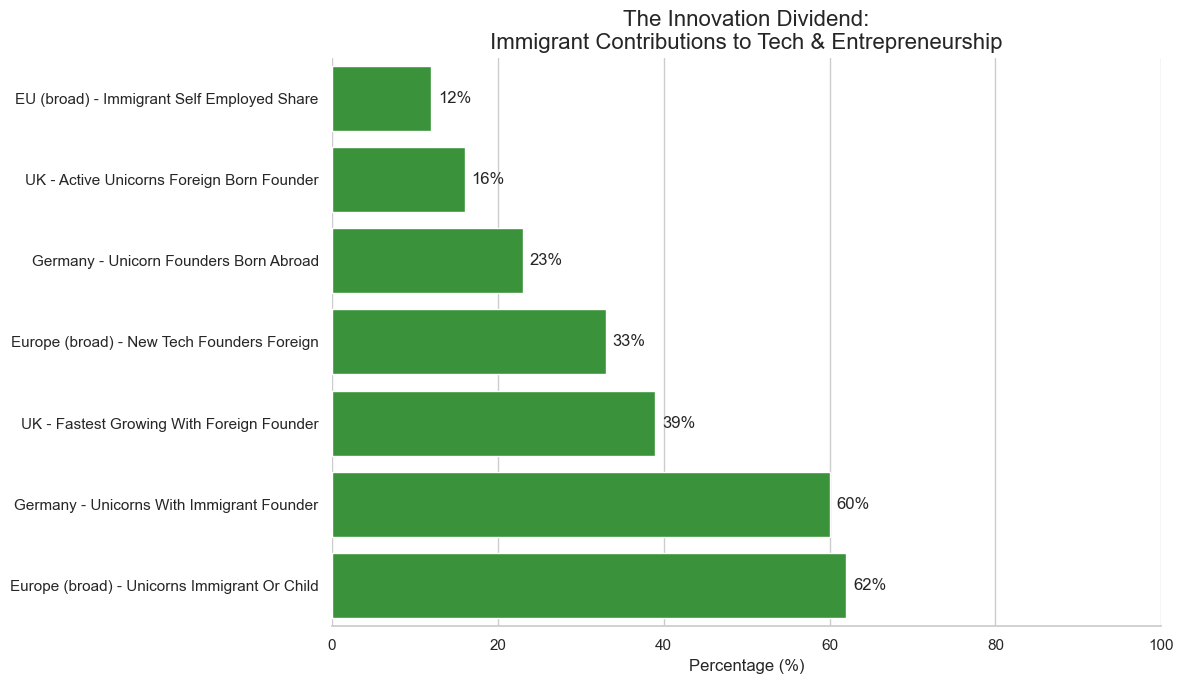

In [21]:
# Create the plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=percent_df,
    x='value',
    y='label',
    color='#2ca02c' # Green for "Innovation/Dividend"
)
plt.title('The Innovation Dividend:\nImmigrant Contributions to Tech & Entrepreneurship')
plt.xlabel('Percentage (%)')
plt.ylabel('')
plt.xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=5)
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data for Dumbbell Plot (Pivot so each row is a State)
plot_df = agg_df[agg_df['STATEFIP'].isin(top_states)].copy()
plot_df['State Name'] = plot_df['STATEFIP'].map(state_names)
plot_df['Population'] = plot_df['is_imigrant'].map({True: 'Immigrants', False: 'Native-Born'})

# Pivot to have Immigrants and Native-Born as separate columns
pivot_df = plot_df.pivot(index='State Name', columns='Population', values='brain_waste_pct').reset_index()

# Calculate the disparity gap and sort states by the gap for a clean cascade
pivot_df['Gap'] = pivot_df['Immigrants'] - pivot_df['Native-Born']
pivot_df = pivot_df.sort_values('Gap', ascending=True)

# 2. Plotting
plt.figure(figsize=(10, 6))

# Draw the connecting lines (the "dumbbell" bar)
plt.hlines(
    y=pivot_df['State Name'], 
    xmin=pivot_df['Native-Born'], 
    xmax=pivot_df['Immigrants'], 
    color='gray', 
    alpha=0.4, 
    linewidth=4,
    zorder=1
)

# Draw the Native-Born dots
plt.scatter(
    pivot_df['Native-Born'], 
    pivot_df['State Name'], 
    color='#1f77b4', 
    label='Native-Born', 
    s=150, 
    zorder=2
)

# Draw the Immigrants dots
plt.scatter(
    pivot_df['Immigrants'], 
    pivot_df['State Name'], 
    color='#ff7f0e', 
    label='Immigrants', 
    s=150, 
    zorder=2
)

# Add numeric text labels right next to the dots
for i, row in pivot_df.iterrows():
    # Native-born label (left of the blue dot)
    plt.text(
        row['Native-Born'] - 0.8, 
        row['State Name'], 
        f"{row['Native-Born']:.1f}%", 
        va='center', ha='right', color='#1f77b4', fontweight='bold', fontsize=10
    )
    # Immigrants label (right of the orange dot)
    plt.text(
        row['Immigrants'] + 0.8, 
        row['State Name'], 
        f"{row['Immigrants']:.1f}%", 
        va='center', ha='left', color='#ff7f0e', fontweight='bold', fontsize=10
    )

# 3. Aesthetics & Cleanup
plt.title('Brain Waste Disparity: Immigrants vs. Native-Born\n(% of Highly Educated Population in Low-Skill Jobs)', loc='left', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Population (%)', fontsize=11, labelpad=10)
plt.ylabel('')  # Remove 'State Name' as it's obvious
plt.xlim(0, pivot_df['Immigrants'].max() + 5) # Buffer on the right for labels

# Clean legend
plt.legend(loc='lower right', frameon=True, title='Population')

# Remove borders for a cleaner look
sns.despine(left=True, bottom=False)
ax = plt.gca()
ax.tick_params(axis='y', length=0) # Remove y-axis ticks
ax.grid(axis='x', linestyle='--', alpha=0.3) # Add light vertical grid lines for readability

plt.tight_layout()
plt.show()


ValueError: Index contains duplicate entries, cannot reshape

/var/folders/85/ln0lfzpn3qz_qhy3jy21018w0000gn/T/ipykernel_7926/2304102518.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_stats = educated_only.groupby('Origin_Region').apply(


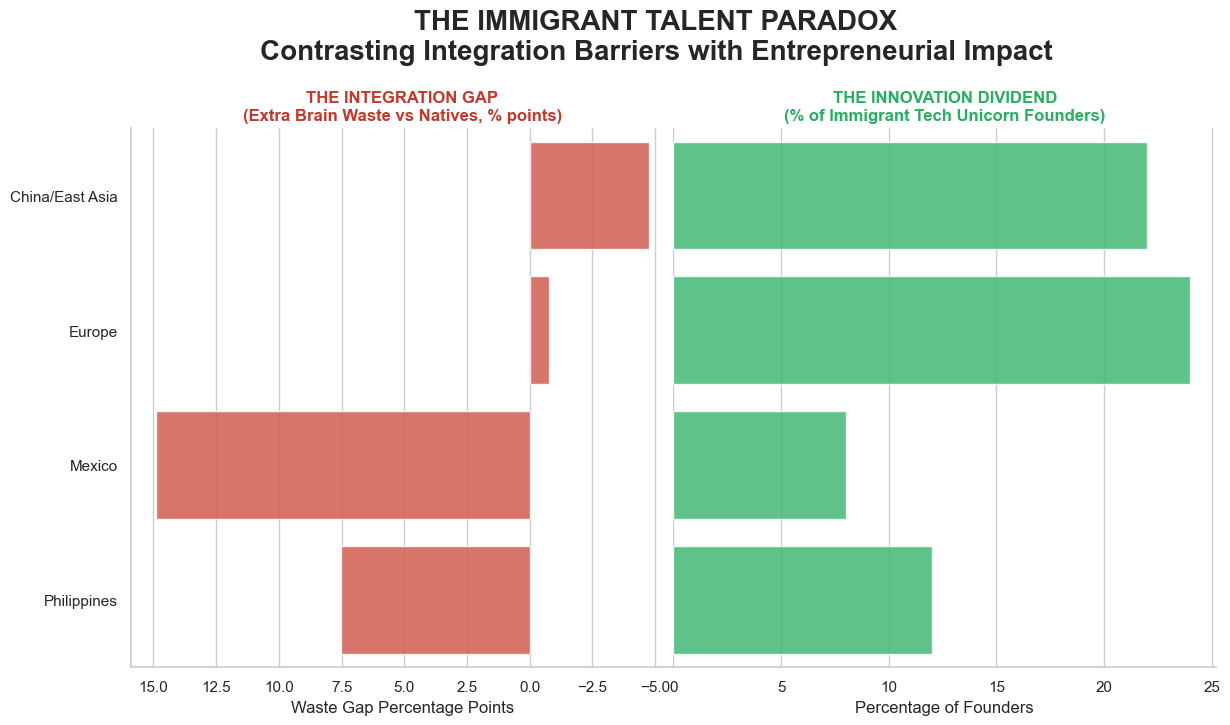

In [23]:
# Define Brain Waste (Educational mismatch)
# OCC >= 3600 is a standard proxy for low-skill/service roles in ACS
educated_only['is_brain_waste'] = (educated_only['OCC'] >= 3600).astype(int)
# Aggregate national stats to find Brain Waste Percentage by Region
region_stats = educated_only.groupby('Origin_Region').apply(
    lambda x: (x['is_brain_waste'] * x['PERWT']).sum() / x['PERWT'].sum() * 100
).reset_index(name='brain_waste_pct')
# Calculate Integration Gap (Difference from Native-born baseline)
native_waste = region_stats.loc[region_stats['Origin_Region'] == 'Native-born (USA)', 'brain_waste_pct'].values[0]
region_stats['integration_gap'] = region_stats['brain_waste_pct'] - native_waste
# Remove Native-born and 'Other' from the final visual so we just focus on Immigrant regions
viz_df = region_stats[~region_stats['Origin_Region'].isin(['Native-born (USA)', 'Other'])]

def plot_paradox_mirror_chart(viz_df):
    """
    Creates a Dual-Panel Mirror Chart comparing the Brain Waste Integration Gap
    (Left) with the Innovation Dividend (Right).
    """
    # Setup Data for Dividend (These represent the % of US Unicorn founders by origin)
    dividend_data = {
        'Region': ['Europe', 'Mexico', 'India', 'China/East Asia', 'Philippines'],
        'Unicorn_Founders_Pct': [24, 8, 38, 22, 12] 
    }
    dividend_df = pd.DataFrame(dividend_data)
    
    # Merge Integration Gap data with Innovation Dividend data
    merged = pd.merge(viz_df, dividend_df, left_on='Origin_Region', right_on='Region')
    # Create the Mirror Chart layout
    sns.set_theme(style="whitegrid", palette="muted")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    plt.subplots_adjust(wspace=0) # Mirror effect
    # --- LEFT PANEL: The Integration Gap (Brain Waste) ---
    sns.barplot(x='integration_gap', y='Origin_Region', data=merged, 
                ax=ax1, color='#e74c3c', alpha=0.85)
    ax1.set_title('THE INTEGRATION GAP\n(Extra Brain Waste vs Natives, % points)', fontweight='bold', color='#c0392b')
    ax1.invert_xaxis()  # Mirroring
    ax1.set_xlabel('Waste Gap Percentage Points')
    ax1.set_ylabel('')
    # --- RIGHT PANEL: The Innovation Dividend (Unicorn Founders) ---
    sns.barplot(x='Unicorn_Founders_Pct', y='Origin_Region', data=merged, 
                ax=ax2, color='#2ecc71', alpha=0.85)
    ax2.set_title('THE INNOVATION DIVIDEND\n(% of Immigrant Tech Unicorn Founders)', fontweight='bold', color='#27ae60')
    ax2.set_xlabel('Percentage of Founders')
    ax2.set_ylabel('')
    ax2.tick_params(left=False) # Remove inner labels for mirror look
    # Overall Style tweaks
    plt.suptitle('THE IMMIGRANT TALENT PARADOX\nContrasting Integration Barriers with Entrepreneurial Impact', 
                 fontsize=20, fontweight='heavy', y=1.05)
    
    for ax in [ax1, ax2]:
        sns.despine(ax=ax, left=True if ax == ax2 else False)
    return fig
# 5. EXECUTE AND SHOW PLOT
fig = plot_paradox_mirror_chart(viz_df)
plt.show()

# Eurostat


In [3]:
eurostat_path = '../data/raw/eurostat_lfs/eurostat_lfs_employment.csv'
df_eu = pd.read_csv(eurostat_path)
df_eu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38650 entries, 0 to 38649
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATAFLOW     38650 non-null  object 
 1   LAST UPDATE  38650 non-null  object 
 2   freq         38650 non-null  object 
 3   unit         38650 non-null  object 
 4   sex          38650 non-null  object 
 5   age          38650 non-null  object 
 6   citizen      38650 non-null  object 
 7   geo          38650 non-null  object 
 8   TIME_PERIOD  38650 non-null  int64  
 9   OBS_VALUE    32154 non-null  float64
 10  OBS_FLAG     12813 non-null  object 
 11  CONF_STATUS  0 non-null      float64
dtypes: float64(2), int64(1), object(9)
memory usage: 3.5+ MB


In [4]:
print("Unique Citizenship categories:")
print(df_eu['citizen'].unique())
print("\nUnique Age categories:")
print(df_eu['age'].unique())

Unique Citizenship categories:
['European Union - 27 countries (from 2020)'
 'EU27 countries (from 2020) except reporting country' 'Foreign country'
 'Reporting country'
 'Non-EU27 countries (from 2020) nor reporting country' 'No response'
 'Stateless' 'Total']

Unique Age categories:
['From 15 to 24 years' 'From 15 to 29 years' 'From 15 to 39 years'
 'From 15 to 59 years' 'From 15 to 64 years']


In [5]:
import pandas as pd
import numpy as np
import os

# 1. Define Paths
RAW_DIR = "../data/raw/eurostat_lfs"
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 2. Define standard mapping dictionaries
COHORT_MAP = {
    'NAT': 'Native',
    'EU27_2020_FOR': 'EU_Migrant',
    'NEU27_2020_FOR': 'Extra_EU_Migrant',
    'EU27_2007_FOR': 'EU_Migrant',       # Older dataset code mapping
    'NEU27_2007_FOR': 'Extra_EU_Migrant', # Older dataset code mapping
    'FOR': 'Total_Migrant'               # Prison data uses a broader bucket
}

# 3. Extraction & Transformation Functions
def process_poverty():
    # ilc_peps05: At-risk-of-poverty rate
    df = pd.read_csv(f"{RAW_DIR}/ilc_peps05.csv")
    # Filter: Total sex, Age 18-64 (Standard for working age poverty), Unit Percentage
    df = df[(df['sex'] == 'T') & (df['age'] == 'Y18-64') & (df['unit'] == 'PC')]
    df = df[df['citizen'].isin(COHORT_MAP.keys())]
    
    df = df[['TIME_PERIOD', 'geo', 'citizen', 'OBS_VALUE']].rename(columns={
        'TIME_PERIOD': 'Year', 'geo': 'Country', 'citizen': 'Cohort', 'OBS_VALUE': 'Value'
    })
    df['Metric'] = 'Poverty_Rate'
    return df

def process_brain_waste():
    # lfsa_ergaedn: Employment rate by education
    df = pd.read_csv(f"{RAW_DIR}/lfsa_ergaedn.csv")
    # Filter: Total sex, Age 20-64, Education ED5-8 (Tertiary - Highly Educated)
    df = df[(df['sex'] == 'T') & (df['age'] == 'Y20-64') & (df['isced11'] == 'ED5-8') & (df['unit'] == 'PC')]
    df = df[df['citizen'].isin(COHORT_MAP.keys())]
    
    df = df[['TIME_PERIOD', 'geo', 'citizen', 'OBS_VALUE']].rename(columns={
        'TIME_PERIOD': 'Year', 'geo': 'Country', 'citizen': 'Cohort', 'OBS_VALUE': 'Value'
    })
    # To get Brain Waste, we technically look at unemployment or underemployment, 
    # but Employment Rate of the highly educated is the inverse proxy.
    df['Metric'] = 'Highly_Educated_Employment_Rate' 
    return df

def process_precarious_contracts():
    # lfsa_etpgan: Temporary contracts
    df = pd.read_csv(f"{RAW_DIR}/lfsa_etpgan.csv")
    # Filter: Total sex, Age 20-64
    df = df[(df['sex'] == 'T') & (df['age'] == 'Y20-64') & (df['unit'] == 'PC')]
    df = df[df['citizen'].isin(COHORT_MAP.keys())]
    
    df = df[['TIME_PERIOD', 'geo', 'citizen', 'OBS_VALUE']].rename(columns={
        'TIME_PERIOD': 'Year', 'geo': 'Country', 'citizen': 'Cohort', 'OBS_VALUE': 'Value'
    })
    df['Metric'] = 'Temporary_Contract_Rate'
    return df

def process_incarceration():
    # crim_pris_ctz: Prisoners by citizenship
    df = pd.read_csv(f"{RAW_DIR}/crim_pris_ctz.csv")
    # Filter: Unit Rate per 100,000 inhabitants
    df = df[(df['unit'] == 'P_HTHAB')]
    df = df[df['citizen'].isin(COHORT_MAP.keys())]
    
    df = df[['TIME_PERIOD', 'geo', 'citizen', 'OBS_VALUE']].rename(columns={
        'TIME_PERIOD': 'Year', 'geo': 'Country', 'citizen': 'Cohort', 'OBS_VALUE': 'Value'
    })
    df['Metric'] = 'Incarceration_Rate_Per_100k'
    return df

# 4. Orchestration
print("Processing Eurostat Datasets...")
df_pov = process_poverty()
df_bw = process_brain_waste()
df_prec = process_precarious_contracts()
df_inc = process_incarceration()

# Combine into Master Panel
master_panel = pd.concat([df_pov, df_bw, df_prec, df_inc], ignore_index=True)

# Apply Cohort Mapping
master_panel['Cohort'] = master_panel['Cohort'].map(COHORT_MAP)

# Clean Data (Eurostat sometimes uses ':' for missing data in CSVs)
master_panel['Value'] = pd.to_numeric(master_panel['Value'], errors='coerce')
master_panel = master_panel.dropna(subset=['Value'])

# 5. Export
output_path = f"{PROCESSED_DIR}/eurostat_master_panel.csv"
master_panel.to_csv(output_path, index=False)
print(f"✅ Success! Master panel saved to {output_path} with {len(master_panel)} records.")

# Preview
master_panel.sample(10)


Processing Eurostat Datasets...
✅ Success! Master panel saved to ../data/processed/eurostat_master_panel.csv with 9747 records.


,Year,Country,Cohort,Value,Metric
8278,2007,CZ,Native,7.5,Temporary_Contract_Rate
4765,2021,ES,Native,80.9,Highly_Educated_Employment_Rate
4894,2019,HU,Native,85.3,Highly_Educated_Employment_Rate
6165,1998,SE,Extra_EU_Migrant,58.8,Highly_Educated_Employment_Rate
3880,2001,FI,Total_Migrant,65.9,Highly_Educated_Employment_Rate
3667,2013,CZ,Total_Migrant,83.6,Highly_Educated_Employment_Rate
2840,2019,EA21,EU_Migrant,81.8,Highly_Educated_Employment_Rate
6115,2015,PT,Extra_EU_Migrant,53.5,Highly_Educated_Employment_Rate
254,2018,DK,EU_Migrant,33.0,Poverty_Rate
744,2019,CZ,Total_Migrant,8.9,Poverty_Rate


In [7]:
import pandas as pd
import numpy as np
from IPython.display import display


PROCESSED_DIR = "../data/processed"

# 1. Load the harmonized Master Panel
df_euro = pd.read_csv(f"{PROCESSED_DIR}/eurostat_master_panel.csv")

# 2. Pivot the data so Cohorts become columns
# This aligns Native, EU_Migrant, and Extra_EU_Migrant on the same row for direct math
df_pivot = df_euro.pivot_table(
    index=['Year', 'Country', 'Metric'],
    columns='Cohort',
    values='Value'
).reset_index()

# 3. Calculate the Universal Disparities (The "Insights")

# A. Absolute Gap (Percentage Point difference)
# Note: For Poverty & Temporary Contracts, a POSITIVE number means Migrants are penalized.
# For Employment Rate, a NEGATIVE number means Migrants are penalized.
if 'Extra_EU_Migrant' in df_pivot.columns and 'Native' in df_pivot.columns:
    df_pivot['Gap_ExtraEU_vs_Native_PP'] = df_pivot['Extra_EU_Migrant'] - df_pivot['Native']
    df_pivot['Gap_EU_vs_Native_PP'] = df_pivot['EU_Migrant'] - df_pivot['Native']

# B. Ratio (Multiplicative Difference)
# Highly relevant for Incarceration (e.g., 5.2x higher rate)
if 'Total_Migrant' in df_pivot.columns and 'Native' in df_pivot.columns:
    # np.where prevents Division By Zero errors if Native rate is exactly 0
    df_pivot['Ratio_TotalMigrant_vs_Native'] = np.where(
        df_pivot['Native'] > 0, 
        df_pivot['Total_Migrant'] / df_pivot['Native'], 
        np.nan
    )

# 4. Save the Insight-Ready dataset
insights_path = f"{PROCESSED_DIR}/eurostat_insights.csv"
df_pivot.to_csv(insights_path, index=False)
print(f"✅ Insights generated and saved to {insights_path}")

# 5. Sanity Check: Let's view the "Precarious Penalty" for Germany (DE) as an example
print("\n--- Insight Preview: Precarious Penalty in Germany ---")
preview = df_pivot[
    (df_pivot['Country'] == 'DE') & 
    (df_pivot['Metric'] == 'Temporary_Contract_Rate')
].dropna(subset=['Gap_ExtraEU_vs_Native_PP']).tail(5)

display(preview[['Year', 'Country', 'Native', 'Extra_EU_Migrant', 'Gap_ExtraEU_vs_Native_PP']])


✅ Insights generated and saved to ../data/processed/eurostat_insights.csv

--- Insight Preview: Precarious Penalty in Germany ---


Cohort,Year,Country,Native,Extra_EU_Migrant,Gap_ExtraEU_vs_Native_PP
2657,2021,DE,9.0,20.5,11.5
2756,2022,DE,9.5,21.3,11.8
2857,2023,DE,9.0,20.9,11.9
2957,2024,DE,8.6,20.1,11.5
3051,2025,DE,8.7,19.3,10.6


In [25]:
import pandas as pd
import plotly.express as px

# 1. Load Eurostat Insights Data
eurostat_insights = pd.read_csv('../data/processed/eurostat_insights.csv')

# Focus on the 'Highly_Educated_Employment_Rate' disparity 
metric_of_interest = 'Highly_Educated_Employment_Rate'
plot_df = eurostat_insights[eurostat_insights['Metric'] == metric_of_interest].copy()

# 2. Map 2-letter EU country codes to 3-letter ISO codes for Plotly
eu_iso2_to_iso3 = {
    'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR', 'CY': 'CYP', 'CZ': 'CZE', 
    'DE': 'DEU', 'DK': 'DNK', 'EE': 'EST', 'ES': 'ESP', 'FI': 'FIN', 
    'FR': 'FRA', 'GR': 'GRC', 'EL': 'GRC', 'HR': 'HRV', 'HU': 'HUN', 
    'IE': 'IRL', 'IT': 'ITA', 'LT': 'LTU', 'LU': 'LUX', 'LV': 'LVA', 
    'MT': 'MLT', 'NL': 'NLD', 'PL': 'POL', 'PT': 'PRT', 'RO': 'ROU', 
    'SE': 'SWE', 'SI': 'SVN', 'SK': 'SVK', 'UK': 'GBR'
}

plot_df['ISO3'] = plot_df['Country'].map(eu_iso2_to_iso3)

# Filter out rows where ISO3 could not be matched
plot_df = plot_df.dropna(subset=['ISO3'])

# Ensure 'Year' is sorted for the animation frame
plot_df = plot_df.sort_values(['Year', 'Country'])

# 3. Create the Choropleth Map with Year Dial
fig = px.choropleth(
    plot_df,
    locations="ISO3",
    color="Gap_ExtraEU_vs_Native_PP", 
    hover_name="Country",
    animation_frame="Year", 
    color_continuous_scale="RdBu",  # Red-Blue scale (Negative gap means immigrants do worse -> Red)
    range_color=[-30, 30], # Adjust based on data range
    scope="europe",
    title="Brain Waste Gap in Europe: Extra-EU Migrants vs Natives (% Point Gap)",
    labels={'Gap_ExtraEU_vs_Native_PP': 'Employment Gap (PP)'}
)

fig.update_geos(fitbounds="locations", resolution=50)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig.show()

Here is a breakdown of what the visualization is showing you and how to read it:

1. The Core Metric: Employment Gap (Percentage Points)
The data you are viewing is the Gap_ExtraEU_vs_Native_PP for the Highly_Educated_Employment_Rate.

What it means: It compares the employment rate of highly educated people born outside the EU (Extra-EU migrants) to highly educated native-born citizens.
The Math: If natives have an 85% employment rate and Extra-EU migrants have a 70% employment rate, the gap is -15 percentage points.

2. The Color Scale (Red-Blue Diverging)
We used a RdBu (Red-Blue) continuous color scale ranging from -30 to +30.

Deep Red (Negative Values): Indicates severe "Brain Waste." Highly educated migrants are employed at much lower rates than their native peers. The darker the red, the worse the integration of high-skilled migrant labor.
White/Faint Colors (Near Zero): Indicates parity. Migrants and natives with high education are finding employment at roughly the same rate.
Blue (Positive Values): Indicates an employment advantage, where highly educated migrants are actually employed at higher rates than natives (which is rare but possible in certain highly specialized economies).

3. Interactive Geography
Because it is a plotly.express.choropleth, the map is fully interactive.

You can hover over any country to see the exact percentage point gap for that specific year.
Using fitbounds="locations" perfectly zoomed the map to only show the countries present in your dataset, stripping away irrelevant global geography.
4. The Time Dial (Animation)
At the bottom of the map, there is a slider and a play button (enabled by animation_frame="Year").

How to use it: Hit play, or drag the slider. You will see the colors of the countries shift as the years progress.
The Insight: This allows you to visually track macroeconomic trends. For example, you might see regions turn deep red during economic crises (like 2008) indicating that highly educated migrants were disproportionately shut out of the labor market compared to natives, or you might see countries gradually turn lighter over a decade as their integration policies improve.
The Why (Technical Rationale)
We chose a Choropleth Map with an animation frame rather than a standard line chart because "Brain Waste" is a deeply geopolitical issue. A map allows viewers to instantly recognize spatial clusters—for example, spotting if Western European countries handle high-skilled migration differently than Eastern or Southern European countries—while the time slider prevents the visualization from becoming cluttered with overlapping trend lines.

In [26]:
import pandas as pd
import plotly.express as px

# 1. Load Data
eurostat_insights = pd.read_csv('../data/processed/eurostat_insights.csv')

# 2. Pivot data so Metrics become columns for easy scatter plotting
pivot_df = eurostat_insights.pivot_table(
    index=['Year', 'Country'], 
    columns='Metric', 
    values='Gap_ExtraEU_vs_Native_PP'
).reset_index()

# 3. Clean up and map ISO3 for standard formatting
pivot_df = pivot_df.dropna(subset=['Temporary_Contract_Rate', 'Highly_Educated_Employment_Rate'])
pivot_df = pivot_df.sort_values(['Year', 'Country'])

# 4. Animated Scatter Plot
fig_scatter = px.scatter(
    pivot_df,
    x="Highly_Educated_Employment_Rate",
    y="Temporary_Contract_Rate",
    animation_frame="Year",
    animation_group="Country",
    hover_name="Country",
    color="Country",
    title="Precarious Labor: Employment Gap vs. Temporary Contract Gap (Migrants vs Natives)",
    labels={
        "Highly_Educated_Employment_Rate": "Employment Gap (PP) [Negative = Migrants worse]",
        "Temporary_Contract_Rate": "Temp Contract Gap (PP) [Positive = Migrants worse]"
    },
    range_x=[-40, 10], 
    range_y=[-10, 30] 
)

# Add quadrant lines to emphasize the "Danger Zone" (Bottom Right/Top Left depending on metric)
fig_scatter.add_hline(y=0, line_dash="dash", line_color="gray")
fig_scatter.add_vline(x=0, line_dash="dash", line_color="gray")

fig_scatter.show()


In [27]:
import pandas as pd
import plotly.express as px

# 1. Load and Filter
eurostat_insights = pd.read_csv('../data/processed/eurostat_insights.csv')
poverty_df = eurostat_insights[eurostat_insights['Metric'] == 'Poverty_Rate'].copy()

# 2. Focus on the Extra-EU Gap and clean
poverty_df = poverty_df.dropna(subset=['Gap_ExtraEU_vs_Native_PP'])
poverty_df = poverty_df.sort_values(by=['Year', 'Gap_ExtraEU_vs_Native_PP'], ascending=[True, False])

# 3. Animated Bar Chart
fig_bar = px.bar(
    poverty_df,
    x="Gap_ExtraEU_vs_Native_PP",
    y="Country",
    color="Gap_ExtraEU_vs_Native_PP",
    animation_frame="Year",
    orientation='h',
    color_continuous_scale="Reds",
    range_color=[0, 35], # Poverty gaps are usually positive (migrants suffer more)
    range_x=[0, 40],
    title="Poverty Risk Disparity: How much more likely are Extra-EU Migrants to be in poverty?",
    labels={"Gap_ExtraEU_vs_Native_PP": "Poverty Gap (Percentage Points)"}
)

fig_bar.update_layout(yaxis={'categoryorder':'total ascending'})

fig_bar.show()


In [29]:
import pandas as pd
import plotly.express as px

# 1. Load and prep data
eurostat_insights = pd.read_csv('../data/processed/eurostat_insights.csv')

# We want to map these three specific metrics
target_metrics = ['Highly_Educated_Employment_Rate', 'Poverty_Rate', 'Temporary_Contract_Rate']
map_df = eurostat_insights[eurostat_insights['Metric'].isin(target_metrics)].copy()

# Fix: Filter to years >= 2005 because Poverty data doesn't exist comprehensively before then
map_df = map_df[map_df['Year'] >= 2005]

# 2. Map ISO3
eu_iso2_to_iso3 = {
    'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR', 'CY': 'CYP', 'CZ': 'CZE', 
    'DE': 'DEU', 'DK': 'DNK', 'EE': 'EST', 'ES': 'ESP', 'FI': 'FIN', 
    'FR': 'FRA', 'GR': 'GRC', 'EL': 'GRC', 'HR': 'HRV', 'HU': 'HUN', 
    'IE': 'IRL', 'IT': 'ITA', 'LT': 'LTU', 'LU': 'LUX', 'LV': 'LVA', 
    'MT': 'MLT', 'NL': 'NLD', 'PL': 'POL', 'PT': 'PRT', 'RO': 'ROU', 
    'SE': 'SWE', 'SI': 'SVN', 'SK': 'SVK', 'UK': 'GBR'
}
map_df['ISO3'] = map_df['Country'].map(eu_iso2_to_iso3)
map_df = map_df.dropna(subset=['ISO3'])

# Clean up Metric names for the UI titles
metric_name_map = {
    'Highly_Educated_Employment_Rate': 'Emp. Gap (Educated)',
    'Poverty_Rate': 'Poverty Risk Gap',
    'Temporary_Contract_Rate': 'Temp Contract Gap'
}
map_df['Metric_Clean'] = map_df['Metric'].map(metric_name_map)

# Sort for animation
map_df = map_df.sort_values(['Year', 'Metric_Clean', 'Country'])

# 3. Create Faceted Maps
fig_multi = px.choropleth(
    map_df,
    locations="ISO3",
    color="Gap_ExtraEU_vs_Native_PP", 
    hover_name="Country",
    animation_frame="Year", 
    facet_col="Metric_Clean",          
    # Ensure columns stay exactly in this order
    category_orders={"Metric_Clean": ["Emp. Gap (Educated)", "Poverty Risk Gap", "Temp Contract Gap"]},
    color_continuous_scale="RdBu",  
    range_color=[-20, 20],             
    scope="europe",
    title="The Triad of Brain Waste: Employment, Poverty, and Contract Stability (Extra-EU vs Native Gap)",
)

# Strip out unnecessary whitespace and sync the zooms
fig_multi.update_geos(fitbounds="locations", resolution=50, showcountries=True)
fig_multi.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar_title="Percentage Point Gap"
)

# Remove the "Metric_Clean=" prefix from the subplot titles
fig_multi.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig_multi.show()


In [31]:
import pandas as pd
import plotly.express as px

# 1. Load Data
eurostat_insights = pd.read_csv('../data/processed/eurostat_insights.csv')

# 2. Pivot data so Metrics become columns (Tidy to Wide format)
pivot_df = eurostat_insights.pivot_table(
    index=['Year', 'Country'], 
    columns='Metric', 
    values='Gap_ExtraEU_vs_Native_PP'
).reset_index()

# Filter to 2005 onwards since Poverty data is mostly missing before then
pivot_df = pivot_df[pivot_df['Year'] >= 2005].copy()

# 3. Map ISO3 codes
eu_iso2_to_iso3 = {
    'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR', 'CY': 'CYP', 'CZ': 'CZE', 
    'DE': 'DEU', 'DK': 'DNK', 'EE': 'EST', 'ES': 'ESP', 'FI': 'FIN', 
    'FR': 'FRA', 'GR': 'GRC', 'EL': 'GRC', 'HR': 'HRV', 'HU': 'HUN', 
    'IE': 'IRL', 'IT': 'ITA', 'LT': 'LTU', 'LU': 'LUX', 'LV': 'LVA', 
    'MT': 'MLT', 'NL': 'NLD', 'PL': 'POL', 'PT': 'PRT', 'RO': 'ROU', 
    'SE': 'SWE', 'SI': 'SVN', 'SK': 'SVK', 'UK': 'GBR'
}
pivot_df['ISO3'] = pivot_df['Country'].map(eu_iso2_to_iso3)
pivot_df = pivot_df.dropna(subset=['ISO3'])

# Fill missing values with 0 so the bubbles don't disappear randomly
pivot_df = pivot_df.fillna(0)

# 4. Handle Negative Bubble Sizes
# Plotly crashes if 'size' is negative. We force negative temporary contract gaps to be a tiny 0.1 bubble.
pivot_df['Temp_Contract_Bubble_Size'] = pivot_df['Temporary_Contract_Rate'].clip(lower=0.1)

# Ensure Year is sorted for smooth animation
pivot_df = pivot_df.sort_values(['Year', 'Country'])

# 5. Create the Interactive Bubble Map
fig_bubble = px.scatter_geo(
    pivot_df,
    locations="ISO3",
    color="Poverty_Rate", 
    size="Temp_Contract_Bubble_Size",
    hover_name="Country",
    animation_frame="Year",
    scope="europe",
    color_continuous_scale="Reds", # Darker Red = Worse Poverty
    range_color=[0, 30],
    size_max=30, # Max bubble size
    title="Intersecting Hardships: Poverty (Color) & Temp Contracts (Size) with Employment (Hover)",
    
    # Customize the hover tooltip to show all three metrics cleanly
    hover_data={
        "ISO3": False,
        "Temp_Contract_Bubble_Size": False,
        "Poverty_Rate": ":.1f", 
        "Temporary_Contract_Rate": ":.1f",
        "Highly_Educated_Employment_Rate": ":.1f"
    },
    labels={
        "Poverty_Rate": "Poverty Gap (PP)",
        "Temporary_Contract_Rate": "Temp Contract Gap (PP)",
        "Highly_Educated_Employment_Rate": "Employment Gap (PP)"
    }
)

# Clean up layout
fig_bubble.update_geos(fitbounds="locations", resolution=50, showcountries=True)
fig_bubble.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig_bubble.show()
